In [2]:
train_dir = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train'

In [3]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

classes = os.listdir(train_dir)
classes.sort()
print("Classes found:", classes)
print("Total number of classes:", len(classes))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Total number of classes: 6


**Task 1**

Load and Visualize One Image Per Class in a Grid

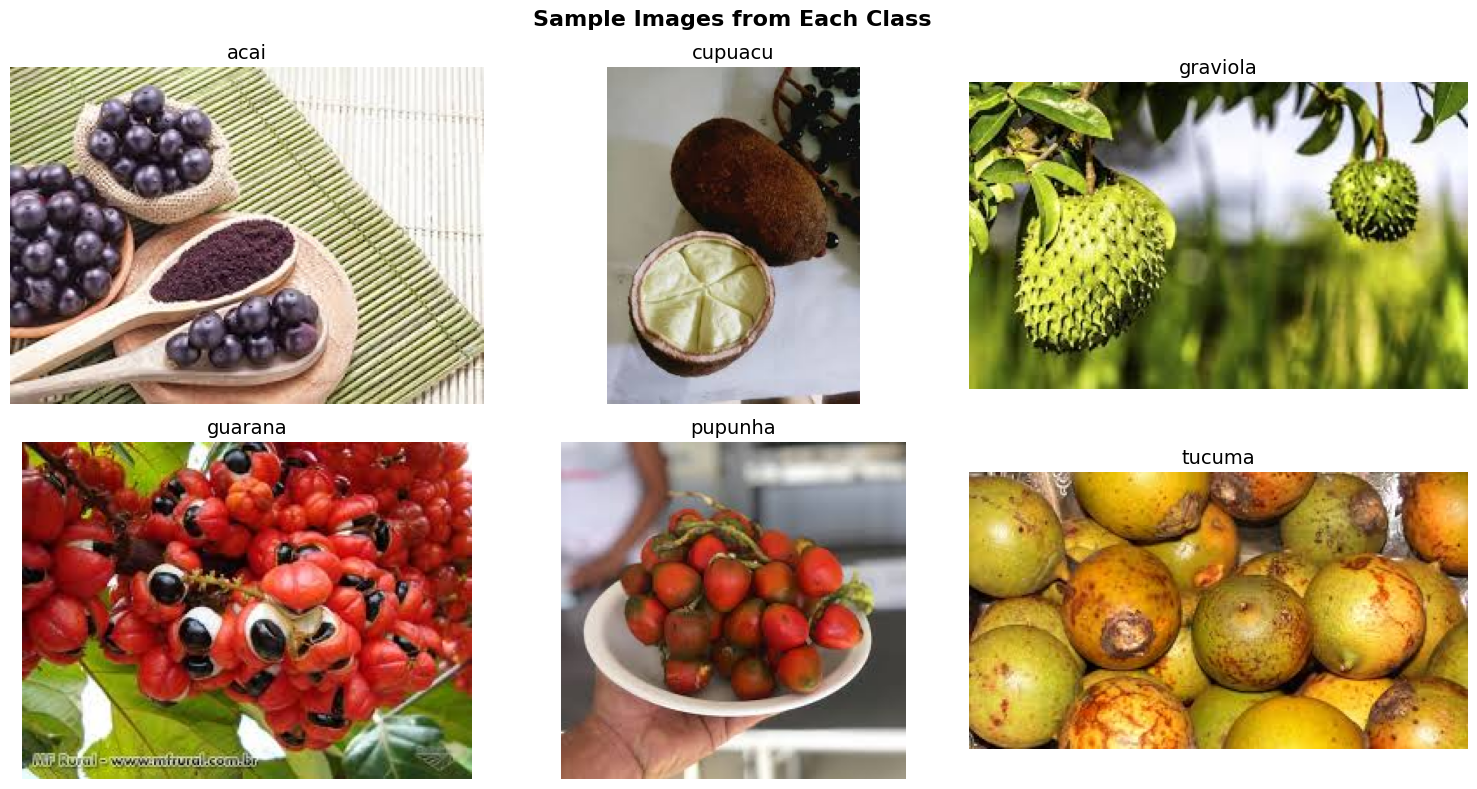


Observation: The dataset contains 6 classes of Amazon fruits.
Each class has images of different sizes, lighting, and backgrounds.
Images vary in viewpoint and appearance within the same class.


In [4]:
num_classes = len(classes)
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))

for idx, class_name in enumerate(classes):
    class_folder = os.path.join(train_dir, class_name)

    images = os.listdir(class_folder)

    random_image = random.choice(images)

    img_path = os.path.join(class_folder, random_image)

    img = mpimg.imread(img_path)

    row = idx // cols
    col = idx % cols

    axes[row, col].imshow(img)
    axes[row, col].set_title(class_name, fontsize=14)
    axes[row, col].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservation: The dataset contains 6 classes of Amazon fruits.")
print("Each class has images of different sizes, lighting, and backgrounds.")
print("Images vary in viewpoint and appearance within the same class.")

**Task 1**

Check for Corrupted Images

In [6]:
from PIL import Image
import os

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_folder = os.path.join(train_dir, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):
            image_path = os.path.join(class_folder, image_name)

            try:
                img = Image.open(image_path)
                img.verify()

            except (IOError, SyntaxError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No corrupted images found.


**Task2**

Loading and Preprocessing Image Data in keras:

In [7]:
import tensorflow as tf

img_height       = 128
img_width        = 128
batch_size       = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names :", class_names)
print("Num classes :", num_classes)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))

for images, labels in train_ds.take(1):
    print("Batch image shape :", images.shape)
    print("Pixel value range :", images.numpy().min(), "to", images.numpy().max())

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6
Batch image shape : (32, 128, 128, 3)
Pixel value range : 0.0 to 1.0


**Task 3**

Build CNN Model

In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Convolutional Block 1
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same',
                  strides=1, activation='relu',
                  input_shape=(img_height, img_width, 3)),

    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Block 2
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same',
                  strides=1, activation='relu'),

    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Fully Connected Network
    layers.Flatten(),

    layers.Dense(64, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4**

Compile and Train

In [9]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath        ='/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    verbose         = 1
)

early_stop = EarlyStopping(
    monitor   = 'val_accuracy',
    patience  = 20,
    verbose   = 1,
    restore_best_weights = True
)

history = model.fit(
    train_ds,
    epochs          = 250,
    batch_size      = 16,
    validation_data = val_ds,
    callbacks       = [checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.1661 - loss: 1.8606
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.1389 - loss: 1.9045 - val_accuracy: 0.0000e+00 - val_loss: 1.8459
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.3247 - loss: 1.6857
Epoch 2: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 743ms/step - accuracy: 0.3333 - loss: 1.6774 - val_accuracy: 0.0000e+00 - val_loss: 1.8345
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.3588 - loss: 1.4926
Epoch 3: val_accuracy improved from 0.00000 to 0.11111, saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 569ms/step - accuracy: 0.3889 - loss: 1.4645 - val_accuracy: 0.1111 - val_loss: 1.7245
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.4844 - loss: 1.2548
Epoch 4: val_accuracy did not improve from 0.11111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 560ms/step - accuracy: 0.5000 - loss: 1.2248 - val_accuracy: 0.0556 - val_loss: 1.6746
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6892 - loss: 1.0395
Epoch 5: val_accuracy improved from 0.11111 to 0.22222, saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 602ms/step - accuracy: 0.7083 - loss: 1.0032 - val_accuracy: 0.2222 - val_loss: 1.3233
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.7812 - loss: 0.7158
Epoch 6: val_accuracy improved from 0.22222 to 0.83333, saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5



Epoch 6: finished saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 587ms/step - accuracy: 0.7500 - loss: 0.7885 - val_accuracy: 0.8333 - val_loss: 0.8325
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8958 - loss: 0.5592
Epoch 7: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 694ms/step - accuracy: 0.8750 - loss: 0.5785 - val_accuracy: 0.6111 - val_loss: 0.9696
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.8953 - loss: 0.4640
Epoch 8: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 856ms/step - accuracy: 0.8889 - loss: 0.4381 - val_accuracy: 0.5000 - val_loss: 0.8872
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.8038 - loss: 0.4081
Epoch 9: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.8333 - loss: 0.3978 - val_accuracy: 0.7778 - val_loss: 0.6695
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━


Epoch 11: finished saving model to /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 573ms/step - accuracy: 1.0000 - loss: 0.1652 - val_accuracy: 0.8889 - val_loss: 0.3213
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.9797 - loss: 0.1293
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 483ms/step - accuracy: 0.9861 - loss: 0.1249 - val_accuracy: 0.8889 - val_loss: 0.4153
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9797 - loss: 0.0814
Epoch 13: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.9861 - loss: 0.0723 - val_accuracy: 0.8333 - val_loss: 0.4149
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 1.0000 - loss: 0.0590
Epoch 14: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 810ms/step - accuracy: 1.0000 - loss: 0.0560 - val_accuracy: 0.8333 - val_loss: 0.6404
Epoch 15/250
3/3 ━━━━━━━━

**Task5:**

Evaluate the Model

In [11]:
test_loss, test_acc = model.evaluate(val_ds)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9444 - loss: 0.3173

Test Loss     : 0.3173
Test Accuracy : 0.9444


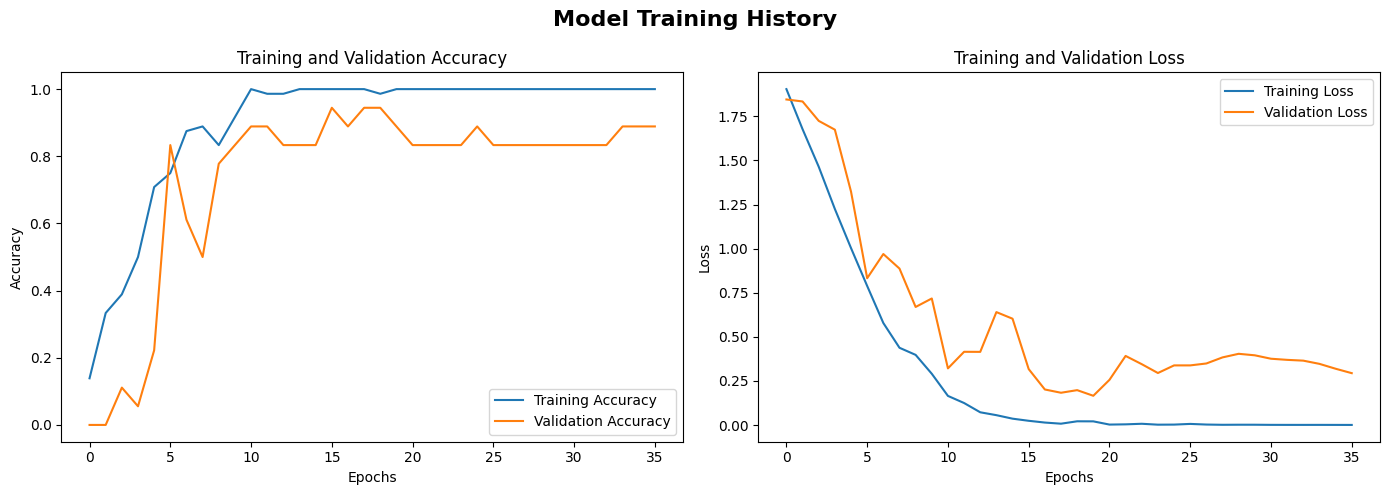

In [12]:
import matplotlib.pyplot as plt

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc,     label='Training Accuracy')
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, loss,     label='Training Loss')
axes[1].plot(epochs_range, val_loss, label='Validation Loss')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Model Training History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Task6**

Save and Load the Model

In [13]:
save_path = '/content/drive/MyDrive/FruitinAmazon/fruit_cnn_model.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/FruitinAmazon/fruit_cnn_model.h5


In [14]:
from tensorflow.keras.models import load_model

loaded_model = load_model(save_path)
print("Model loaded successfully!")

loaded_loss, loaded_acc = loaded_model.evaluate(val_ds)
print(f"\nLoaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f}")

Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step - accuracy: 0.9444 - loss: 0.3173

Loaded Model Test Loss     : 0.3173
Loaded Model Test Accuracy : 0.9444


Task 7

Predictions and Classification Report

In [15]:
import numpy as np
from sklearn.metrics import classification_report

class_names = ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

test_dir = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/test'

rescale = tf.keras.layers.Rescaling(1./255)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (128, 128),
    interpolation = 'nearest',
    batch_size    = 32,
    shuffle       = False,
    seed          = 123
)

class_names = test_ds.class_names
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions    = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classes found:", class_names)
print("Unique y_true:", np.unique(y_true))
print("Unique y_pred:", np.unique(y_pred))

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Found 30 files belonging to 6 classes.
Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Unique y_true: [0 1 2 3 4 5]
Unique y_pred: [0 1 2 3 4 5]

Classification Report:
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       1.00      0.40      0.57         5
    graviola       0.42      1.00      0.59         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.86      0.73      0.73        30
weighted avg       0.86      0.73      0.73        30



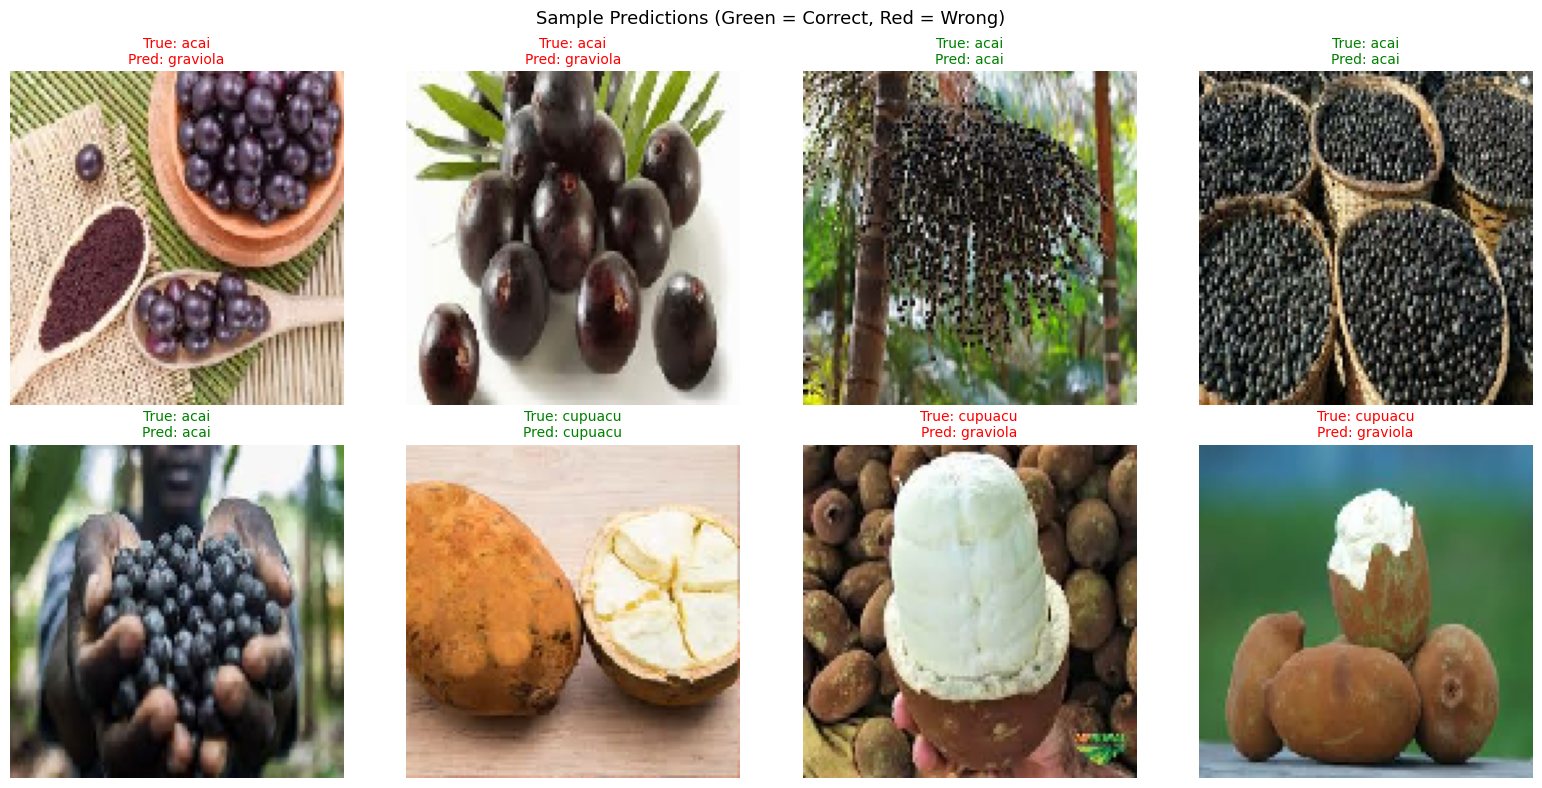

In [18]:
sample_images, sample_labels = next(iter(test_ds))
sample_preds = loaded_model.predict(sample_images, verbose=0)
sample_pred_cls = np.argmax(sample_preds, axis=1)

n_show = min(8, len(sample_images))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(sample_images[i].numpy())
    true_cls = class_names[sample_labels[i]]
    pred_cls = class_names[sample_pred_cls[i]]
    colour   = 'green' if true_cls == pred_cls else 'red'
    axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}",
                      color=colour, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()